<a href="https://colab.research.google.com/github/sierramendoza543/sierra-gating-project/blob/main/edits_syntheticdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

#testedit

seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


Step 2

In [ ]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 4
mu_background = 2
sigma2 = 0.16
dispersion = 50.0

size_factor_mean = 2000
size_factor_sd = 300

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 4


Step 3

In [ ]:
# Step 3: create patient metadata

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups
})

patients_df

,patient_id,group
0,P1,Group1
1,P2,Group1
2,P3,Group1
3,P4,Group1
4,P5,Group1
5,P6,Group1
6,P7,Group1
7,P8,Group1
8,P9,Group1
9,P10,Group1


Step 4

In [ ]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


Step 5

In [ ]:
# Step 5: label genes

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})

genes_df.head(10)

,gene_id,gene_type
0,G1,signal
1,G2,signal
2,G3,signal
3,G4,signal
4,G5,signal
5,G6,signal
6,G7,signal
7,G8,signal
8,G9,signal
9,G10,signal


Step 6

In [ ]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,gamma_i
0,P1,Group1,0.559742
1,P2,Group1,0.369853
2,P3,Group1,0.023852
3,P4,Group1,-0.258775
4,P5,Group1,0.279289
5,P6,Group1,0.157394
6,P7,Group1,0.358077
7,P8,Group1,0.254069
8,P9,Group1,0.419821
9,P10,Group1,-0.214094


Step 7

In [ ]:
# Step 7: define group-specific means

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal =", mu_group1_signal)
print("mu_group2_signal =", mu_group2_signal)
print("mu_group1_background =", mu_group1_background)
print("mu_group2_background =", mu_group2_background)

mu_group1_signal = 8
mu_group2_signal = 2
mu_group1_background = 2
mu_group2_background = 2


Step 8

In [ ]:
# Step 8: simulate gene expression counts (cleaner NB parameterization)

from scipy.stats import nbinom

count_rows = []

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]

    if group == "Group1":
        signal_mu_base = mu_group1_signal
        background_mu_base = mu_group1_background
    else:
        signal_mu_base = mu_group2_signal
        background_mu_base = mu_group2_background

    signal_mu = signal_mu_base + gamma_i
    background_mu = background_mu_base #can try to remove, easier if you remove if sigma
# make sure std dev is lesser than the mu (gamma i shouldnt be too big), can set mu to 2 and
# keep gamma i 0.4,
    for gene_id in signal_gene_ids:
        mu = size_factor * signal_mu
        var = mu + (mu**2) / dispersion #you can try increasing this because mu is 4000-16000
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "signal",
            "expression": expr
        })
# check for correlation with spearmann or pearson coefficient
    for gene_id in background_gene_ids:
        mu = size_factor * background_mu
        var = mu + (mu**2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)
counts_df.head()

,patient_id,group,cell_id,gene_id,gene_type,expression
0,P1,Group1,P1_C1,G1,signal,19661
1,P1,Group1,P1_C1,G2,signal,16702
2,P1,Group1,P1_C1,G3,signal,17703
3,P1,Group1,P1_C1,G4,signal,14225
4,P1,Group1,P1_C1,G5,signal,18953


Step 9

In [ ]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,15066,15778,17325,14922,14299,18544,16287,14349,15849,17830,...,18996,20004,14456,18824,14331,14687,22503,18116,13093,18628
G10,15274,14368,18708,14859,14584,14714,14277,11808,15313,19255,...,19514,18957,13339,12759,13638,12226,18545,10824,17002,16029
G100,14340,10925,21267,18914,14295,10783,16237,15925,15720,16688,...,19113,14981,18707,17110,13267,12107,17188,11592,16089,17006
G1000,3480,2805,4393,3840,3427,3705,3635,3188,4794,4299,...,5003,3603,3712,4359,2325,3437,3671,3305,4463,4058
G101,4149,3212,5817,4561,4128,3768,3299,3031,4218,3783,...,5619,3685,2985,3803,3812,3668,3833,3055,4493,4275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,3595,3941,5189,4023,2719,3777,4023,3465,3751,4781,...,4790,3610,3677,3743,3559,3136,4675,3242,3845,4675
G996,4202,3610,5711,4057,3010,4299,4534,3130,5657,4864,...,6071,4241,4425,3319,5606,3035,3762,3296,4259,3755
G997,3442,3841,5150,4748,3426,3912,4518,4003,3905,4603,...,4862,3986,3542,3989,3441,2927,4518,3454,3478,5346


Step 10

In [ ]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,10376.807,8306.0,6656.393141,2139,30167
1,G10,signal,10408.644,8338.5,6554.225641,1848,28909
2,G100,signal,10468.274,8344.5,6670.402093,1861,27312
3,G1000,background,3985.956,3894.5,846.484445,1783,7064
4,G101,background,3998.583,3937.5,789.016461,1931,7668
5,G102,background,4000.882,3971.0,807.165024,1848,7163
6,G103,background,4001.462,3948.5,818.236224,1864,8692
7,G104,background,4001.345,3961.0,804.000001,1811,7861
8,G105,background,3972.636,3920.5,781.505875,1659,7010
9,G106,background,4062.332,3992.0,821.492365,2103,7148


Step 11

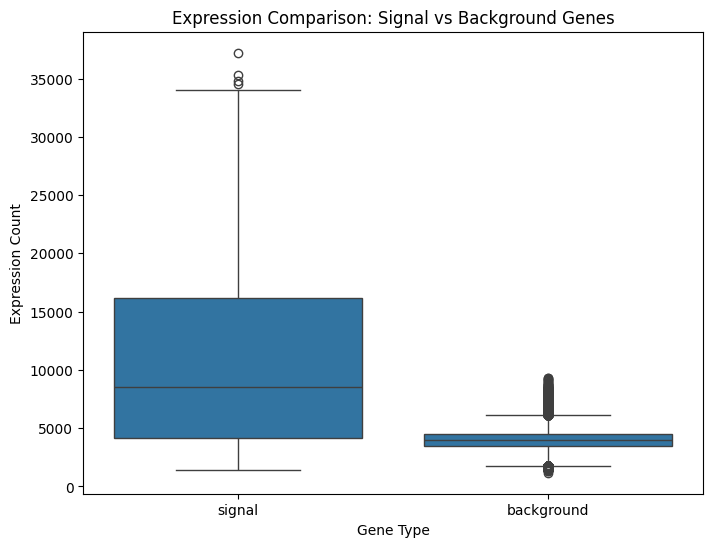

In [ ]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

Step 12

# L1 Gating Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit

In [ ]:
# Build cell-level matrix
X_df = counts_df.pivot_table(
    index="cell_id",
    columns="gene_id",
    values="expression",
    aggfunc="sum",
    fill_value=0
)

cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values

gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]

In [ ]:
# Split and train L1 model
# X_train, X_test, y_train, y_test = train_test_split(
#     X_df.values, y, test_size=0.2, random_state=42, stratify=y
# )

groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))

X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

#cross validation for lambda tuning, define loss function
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.05,  #C=1/Lambda. Low C- strong regularization, high C- weak regularization
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.99875
Test accuracy: 0.995


In [ ]:
# Extract gene scores
coef = model.coef_[0]

feature_scores = pd.DataFrame({
    "gene_id": X_df.columns,
    "gene_type": gene_types.values,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

feature_scores.head()

,gene_id,gene_type,coef,abs_coef
0,G1,signal,-0.131998,0.131998
1,G10,signal,0.000000,0.000000
2,G100,signal,-0.293646,0.293646
3,G1000,background,0.000000,0.000000
4,G101,background,0.000000,0.000000


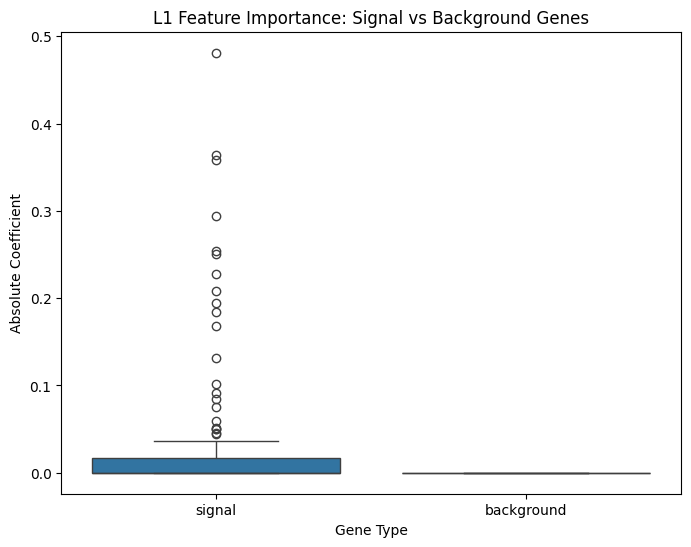

In [ ]:
# Compare signal vs. background
plt.figure(figsize=(8, 6))
sns.boxplot(data=feature_scores, x="gene_type", y="abs_coef")
plt.title("L1 Feature Importance: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Absolute Coefficient")
plt.show()

In [ ]:
# Long format (one row per cell-gene pair) — good for records/reproducibility
#counts_df.to_csv("counts_long.csv", index=False)

# Wide format (genes as rows, cells as columns) — good for feeding into a model
#expression_matrix.to_csv("expression_matrix.csv")

# Gene answer key (which genes are signal vs background)
#genes_df.to_csv("genes_labels.csv", index=False)

# Patient metadata (group, gamma_i)
#patients_df.to_csv("patients.csv", index=False)